## Block 1 — Environment, configuration and reporting utilities

In [1]:
# ======================================================================
# BLOCK 1 — ENVIRONMENT, CONFIGURATION & REPORTING UTILITIES
# ======================================================================
import os, sys, io, gzip, json, time, math, random, warnings, subprocess, importlib, re
from pathlib import Path
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)


def ensure_package(pip_name, import_name=None):
    name = import_name or pip_name
    try:
        importlib.import_module(name)
        return True
    except ImportError:
        if os.environ.get("ALS_V3_OFFLINE") == "1":
            return False
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pip_name], capture_output=True)
        try:
            importlib.import_module(name)
            return True
        except ImportError:
            return False


ensure_package("xlrd")
import requests
import scipy
import sklearn
import torch
import torch.nn as nn
from tqdm.auto import tqdm
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

try:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = Path("/content/drive/MyDrive/ALS_MultiOmics_v3")
except ImportError:
    PROJECT_ROOT = Path(os.environ.get("ALS_V3_PROJECT_ROOT", "./ALS_MultiOmics_v3"))

DIRS = {k: PROJECT_ROOT / k for k in ["data/raw", "models", "predictions", "metrics", "biomarkers", "figures", "tables", "logs", "cache", "inference_package"]}
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)
RAW_DIR = DIRS["data/raw"]


@dataclass
class Config:
    seed: int = 42
    n_folds: int = 5
    n_repeats: int = 3
    min_mean_count: float = 5.0          # drop near-unexpressed miRNAs (training-fold statistics only)
    n_mirna: int = 512                   # top-variance miRNAs kept (training-fold statistics only)
    max_epochs: int = 200
    patience: int = 25
    batch_size: int = 24
    final_seeds: tuple = (42, 52, 62, 72, 82)
    ablation_seeds: tuple = (42, 52, 62)
    rf_trees: int = 400
    n_bootstrap: int = 2000
    test_size: float = 0.2               # held-out, scored once


CFG = Config()
FAST = os.environ.get("ALS_V3_FAST") == "1"
if FAST:
    CFG = Config(n_folds=3, n_repeats=1, n_mirna=128, max_epochs=15, patience=5, final_seeds=(42, 52),
                 ablation_seeds=(42,), rf_trees=50, n_bootstrap=50)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(CFG.seed)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_COLORS = {}
mpl.rcParams.update({"figure.dpi": 110, "savefig.dpi": 300, "font.size": 10, "axes.titlesize": 11,
                     "axes.titleweight": "bold", "axes.labelsize": 10, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False})


def banner(title, char="="):
    print("\n" + char * 96 + f"\n{title}\n" + char * 96)


class Report:
    def __init__(self):
        self.figures, self.tables = {}, {}

    @staticmethod
    def _number(registry, name):
        registry.setdefault(name, len(registry) + 1)
        return registry[name]

    def figure(self, fig, name, caption):
        n = self._number(self.figures, name)
        path = DIRS["figures"] / f"Figure_{n:02d}_{name}.png"
        fig.savefig(path, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print(f"Figure {n:02d} — {caption}   [{path.name}]")

    def table(self, df, name, caption, precision=4, maximize=(), minimize=(), model_col="model"):
        n = self._number(self.tables, name)
        path = DIRS["tables"] / f"Table_{n:02d}_{name}.csv"
        df.to_csv(path, index=False)
        banner(f"Table {n:02d} — {caption}", "-")
        styler = df.style.format(precision=precision, thousands=",").hide(axis="index")
        styler = styler.set_table_styles([{"selector": "th", "props": "background-color:#2C3E50;color:white;text-align:center"}])
        good = "background-color:#D5F5E3;font-weight:bold"
        if maximize:
            styler = styler.highlight_max(subset=[c for c in maximize if c in df.columns], props=good)
        if minimize:
            styler = styler.highlight_min(subset=[c for c in minimize if c in df.columns], props=good)
        display(styler)
        print(f"[{path.name}]")


REPORT = Report()
MANIFEST = {"created": time.strftime("%Y-%m-%d %H:%M:%S"), "config": asdict(CFG), "fast_mode": FAST,
           "data_source": "GSE168714 (Magen et al., Nat Neurosci 2021) — public, no data-use agreement required",
           "modality_disclosure": "CNN and RNN branches both use circulating miRNA-seq (baseline vs. repeated visits); "
                                  "this is NOT multi-omics and the RNN branch is NOT clinical/EHR data -- no public, "
                                  "DUA-free dataset with real multi-omics + real longitudinal clinical data for the "
                                  "same rare-disease patients was found."}

banner("BLOCK 1 — ENVIRONMENT READY")
env = pd.DataFrame([("Python", sys.version.split()[0]), ("NumPy", np.__version__), ("pandas", pd.__version__),
                    ("SciPy", scipy.__version__), ("scikit-learn", sklearn.__version__), ("PyTorch", torch.__version__),
                    ("Device", str(DEVICE)), ("Project root", str(PROJECT_ROOT)), ("Smoke-test mode", FAST)],
                   columns=["item", "value"])
env["value"] = env["value"].astype(str)
REPORT.table(env, "environment", "Computational environment")
MANIFEST["environment"] = dict(zip(env["item"], env["value"]))


Mounted at /content/drive

BLOCK 1 — ENVIRONMENT READY

------------------------------------------------------------------------------------------------
Table 01 — Computational environment
------------------------------------------------------------------------------------------------


item,value
Python,3.13.15
NumPy,2.1.3
pandas,2.2.3
SciPy,1.16.3
scikit-learn,1.6.1
PyTorch,2.11.0+cu128
Device,cuda
Project root,/content/drive/MyDrive/ALS_MultiOmics_v3
Smoke-test mode,False


[Table_01_environment.csv]


## Block 2 — Download GSE168714 (public, no login, no data-use agreement)

Pulls the four supplementary files this notebook needs directly from the GEO FTP mirror. Nothing here requires an account or an application.

In [2]:
# ======================================================================
# BLOCK 2 — DOWNLOAD GSE168714 SUPPLEMENTARY FILES
# ======================================================================
banner("BLOCK 2 — DOWNLOAD GSE168714")

GEO_BASE = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE168nnn/GSE168714/suppl"
FILES = {
    "enrolment": "GSE168714_All_samples_enrolment.txt.gz",
    "controls": "GSE168714_Controls_only.txt.gz",
    "longitudinal": "GSE168714_Longitudinal_raw_counts_22_samples.txt.gz",
    "clinical": "GSE168714_Data_file_related_to_fig_2_3_5_discovery.csv.gz",
}


def download(name, min_bytes=500):
    dest = RAW_DIR / name
    if dest.exists() and dest.stat().st_size > min_bytes:
        print(f"✓ Using existing {name} ({dest.stat().st_size / 1e3:.0f} KB)")
        return dest
    url = f"{GEO_BASE}/{name}"
    for attempt in range(3):
        try:
            with requests.get(url, stream=True, timeout=120) as r:
                r.raise_for_status()
                tmp = dest.with_suffix(dest.suffix + ".part")
                with open(tmp, "wb") as fh:
                    for chunk in r.iter_content(chunk_size=1 << 20):
                        fh.write(chunk)
            if tmp.stat().st_size < min_bytes:
                raise IOError("downloaded file too small")
            tmp.replace(dest)
            print(f"✓ Downloaded {name} ({dest.stat().st_size / 1e3:.0f} KB)")
            return dest
        except Exception as err:
            print(f"  attempt {attempt + 1} failed: {err}")
            time.sleep(3 * (attempt + 1))
    raise RuntimeError(f"Could not download {name}. Check the internet connection.")


PATHS = {key: download(fname) for key, fname in FILES.items()}
MANIFEST["source_files"] = {k: v.name for k, v in PATHS.items()}
print("✓ All GSE168714 files present — no login or data-use agreement was required.")



BLOCK 2 — DOWNLOAD GSE168714
✓ Using existing GSE168714_All_samples_enrolment.txt.gz (393 KB)
✓ Using existing GSE168714_Controls_only.txt.gz (199 KB)
✓ Using existing GSE168714_Longitudinal_raw_counts_22_samples.txt.gz (181 KB)
✓ Using existing GSE168714_Data_file_related_to_fig_2_3_5_discovery.csv.gz (7 KB)
✓ All GSE168714 files present — no login or data-use agreement was required.


## Block 3 — Parse into a patient-level dataset

Builds three aligned objects, all keyed by the same GEO sample ID:
* **`MIRNA_BASELINE`** — one miRNA profile per patient (ALS + Control), for the CNN branch.
* **`LONGITUDINAL`** — repeat-visit miRNA trajectories for the 22 ALS patients who have them, for the RNN branch.
* **`CLINICAL`** — per-ALS-patient covariates (age, sex, riluzole, ALSFRS-R, FVC, C9ORF72, NfL, survival), recorded **once** at enrolment — used for explainability cross-checks only, never fed into the network (this dataset has no repeated clinical visits to use).

In [3]:
# ======================================================================
# BLOCK 3 — PARSE GSE168714 INTO A PATIENT-LEVEL DATASET
# ======================================================================
banner("BLOCK 3 — PARSE DATASET")


def read_gz_table(path, meta_rows):
    """A GEO miRNA matrix: first `meta_rows` lines are per-sample metadata (tab-separated,
    first column = field name), one of which repeats the sample IDs; remaining lines are
    `mirna_name <TAB> count ...`. Returns (meta_df indexed by sample, counts_df: mirna x sample)."""
    with gzip.open(path, "rt", encoding="utf-8", errors="replace") as fh:
        lines = fh.readlines()
    header = lines[0].rstrip("\n").split("\t")
    sample_ids = [s.strip() for s in header[1:]]
    meta = {}
    counts_rows, counts_idx = [], []
    for line in lines[1:]:
        parts = line.rstrip("\n").split("\t")
        key, vals = parts[0], parts[1:]
        if len(meta) < meta_rows - 1 and not re.match(r"^hsa-", key):
            meta[key] = vals
            continue
        if key.lower() == "sample":
            continue
        try:
            counts_rows.append([float(v) if v not in ("", "NA", "NaN") else np.nan for v in vals])
            counts_idx.append(key)
        except ValueError:
            meta[key] = vals
    meta_df = pd.DataFrame(meta, index=sample_ids)
    counts_df = pd.DataFrame(counts_rows, index=counts_idx, columns=sample_ids)
    counts_df = counts_df.loc[~counts_df.index.duplicated()]
    return meta_df, counts_df


als_meta, als_counts = read_gz_table(PATHS["enrolment"], meta_rows=5)
ctrl_meta, ctrl_counts = read_gz_table(PATHS["controls"], meta_rows=3)

common_mirna = als_counts.index.intersection(ctrl_counts.index)
print(f"ALS enrolment: {als_counts.shape[1]} patients × {als_counts.shape[0]} miRNAs")
print(f"Controls:      {ctrl_counts.shape[1]} patients × {ctrl_counts.shape[0]} miRNAs")
print(f"Shared miRNA panel: {len(common_mirna)}")

baseline_counts = pd.concat([als_counts.loc[common_mirna], ctrl_counts.loc[common_mirna]], axis=1)
baseline_ids = baseline_counts.columns.to_numpy()
baseline_label = np.concatenate([np.ones(als_counts.shape[1]), np.zeros(ctrl_counts.shape[1])]).astype(int)
MIRNA_NAMES = baseline_counts.index.to_numpy()
X_BASELINE = baseline_counts.T.to_numpy(dtype=np.float32)         # patients x miRNA, raw counts
X_BASELINE_LOG = np.log1p(X_BASELINE)                              # deterministic transform, no fitted parameters -> no leakage

assert len(baseline_ids) == len(set(baseline_ids)), "Duplicate patient IDs across ALS/Control cohorts."
assert X_BASELINE.shape == (len(baseline_ids), len(MIRNA_NAMES))

# ----------------------------------------------------------------------
# Longitudinal (RNN) data: 22 ALS patients, 4 real repeat visits each.
# The file has exactly 4 metadata rows (time, subject, group, sample) with
# no separate leading header row -- miRNA count rows start immediately after.
# ----------------------------------------------------------------------
with gzip.open(PATHS["longitudinal"], "rt", encoding="utf-8", errors="replace") as fh:
    long_lines = fh.readlines()
long_time = [c.strip() for c in long_lines[0].rstrip("\n").split("\t")[1:]]
long_subject = [c.strip() for c in long_lines[1].rstrip("\n").split("\t")[1:]]
long_group = [c.strip() for c in long_lines[2].rstrip("\n").split("\t")[1:]]
long_sample_row = [c.strip() for c in long_lines[3].rstrip("\n").split("\t")[1:]]
assert long_lines[4].split("\t", 1)[0].strip().startswith("hsa-"), \
    f"Expected miRNA counts on line 5 of the longitudinal file, got: {long_lines[4][:40]!r}"

long_rows, long_idx = [], []
for line in long_lines[4:]:
    parts = line.rstrip("\n").split("\t")
    key, vals = parts[0], parts[1:]
    if not re.match(r"^hsa-", key):
        continue
    long_rows.append([float(v) if v not in ("", "NA", "NaN") else np.nan for v in vals])
    long_idx.append(key)
long_counts = pd.DataFrame(long_rows, index=long_idx, columns=[f"{s}_{t}" for s, t in zip(long_subject, long_time)])
long_counts = long_counts.loc[~long_counts.index.duplicated()]

long_mirna = long_counts.index.intersection(MIRNA_NAMES)
print(f"Longitudinal: {len(set(long_subject))} unique ALS patients × up to 4 visits, {len(long_mirna)} miRNAs shared with baseline panel")

visit_order = {"A": 0, "B": 1, "C": 2, "D": 3}
MAX_VISITS = 4
N_LONG_FEATURES = len(long_mirna)
LONGITUDINAL = {}          # patient_id -> (log1p_seq[MAX_VISITS, N_LONG_FEATURES] RAW (unscaled), mask[MAX_VISITS])
for subj in sorted(set(long_subject)):
    if subj not in baseline_ids:
        continue           # keep only patients also present in the baseline cohort (same-patient guarantee)
    cols = [f"{subj}_{t}" for t, v in visit_order.items() if f"{subj}_{t}" in long_counts.columns]
    seq = np.zeros((MAX_VISITS, N_LONG_FEATURES), dtype=np.float32)
    mask = np.zeros(MAX_VISITS, dtype=np.float32)
    for col in cols:
        t = col.rsplit("_", 1)[1]
        vidx = visit_order[t]
        raw = long_counts.loc[long_mirna, col].fillna(0.0).to_numpy(dtype=np.float32)
        seq[vidx] = np.log1p(raw)                    # log1p is deterministic; per-fold scaling happens later
        mask[vidx] = 1.0
    if mask.sum() >= 2:     # need at least 2 real visits for a meaningful sequence
        LONGITUDINAL[subj] = (seq, mask)

print(f"✓ Genuine longitudinal RNN data available for {len(LONGITUDINAL)} of {len(baseline_ids)} patients "
      f"({len(LONGITUDINAL) / (baseline_label == 1).sum() * 100:.0f}% of ALS patients). "
      f"Every other patient (including all controls) has the RNN branch masked out, not fabricated. "
      f"This IS confounded with label (only ALS patients have it, by construction of this cohort) -- see Block 8 "
      f"for why the model is still evaluated primarily by its CNN-only behaviour on the full test set.")

# ----------------------------------------------------------------------
# Clinical covariates (auxiliary; explainability + a clinical baseline only).
# Recorded ONCE at enrolment -- there is no repeated clinical measurement in
# this dataset, so it is never fed into the RNN branch.
# ----------------------------------------------------------------------
CLINICAL = pd.read_csv(PATHS["clinical"], compression="gzip").rename(columns={"index case": "sample_id"}).set_index("sample_id")
CLINICAL = CLINICAL[~CLINICAL.index.duplicated()]
print(f"Clinical covariates (cross-sectional, enrolment only): {CLINICAL.shape[0]} ALS patients × {CLINICAL.shape[1]} fields "
      f"({(CLINICAL.index.isin(baseline_ids)).sum()} match the baseline cohort by ID)")

composition = pd.DataFrame([
    ("ALS patients (baseline)", int((baseline_label == 1).sum())),
    ("Control patients (baseline)", int((baseline_label == 0).sum())),
    ("Total baseline patients", len(baseline_ids)),
    ("miRNA features (shared ALS/Control panel)", len(MIRNA_NAMES)),
    ("Patients with genuine longitudinal (RNN) data", len(LONGITUDINAL)),
    ("Patients with clinical covariates", int(CLINICAL.index.isin(baseline_ids).sum())),
], columns=["item", "value"])
REPORT.table(composition, "cohort_composition", "GSE168714 cohort composition (this notebook)", precision=0)
MANIFEST["data"] = {"patients": len(baseline_ids), "als": int((baseline_label == 1).sum()),
                    "control": int((baseline_label == 0).sum()), "mirna_features": len(MIRNA_NAMES),
                    "longitudinal_patients": len(LONGITUDINAL)}



BLOCK 3 — PARSE DATASET
ALS enrolment: 253 patients × 1847 miRNAs
Controls:      103 patients × 1838 miRNAs
Shared miRNA panel: 1838
Longitudinal: 22 unique ALS patients × up to 4 visits, 1838 miRNAs shared with baseline panel
✓ Genuine longitudinal RNN data available for 22 of 356 patients (9% of ALS patients). Every other patient (including all controls) has the RNN branch masked out, not fabricated. This IS confounded with label (only ALS patients have it, by construction of this cohort) -- see Block 8 for why the model is still evaluated primarily by its CNN-only behaviour on the full test set.
Clinical covariates (cross-sectional, enrolment only): 126 ALS patients × 50 fields (122 match the baseline cohort by ID)

------------------------------------------------------------------------------------------------
Table 02 — GSE168714 cohort composition (this notebook)
------------------------------------------------------------------------------------------------


item,value
ALS patients (baseline),253
Control patients (baseline),103
Total baseline patients,356
miRNA features (shared ALS/Control panel),"1,838"
Patients with genuine longitudinal (RNN) data,22
Patients with clinical covariates,122


[Table_02_cohort_composition.csv]


## Block 4 — Patient-level split and fold-safe preprocessing contract

Split first. Everything that *learns* from data — which miRNAs pass the expression/variance filter, the CNN family ordering derived from that selection, and both scalers — is now wrapped in `fit_preprocessing(train_idx)`, called separately inside **every** CV fold and once more on the full development set for the frozen final model. No selection or scaling step ever sees a patient before that patient is assigned to a training fold.

In [4]:
# ======================================================================
# BLOCK 4 — PATIENT-LEVEL SPLIT & FOLD-SAFE PREPROCESSING CONTRACT
# ======================================================================
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler

banner("BLOCK 4 — PATIENT-LEVEL SPLIT & FOLD-SAFE PREPROCESSING")

idx_all = np.arange(len(baseline_ids))
idx_dev, idx_test = train_test_split(idx_all, test_size=CFG.test_size, stratify=baseline_label, random_state=CFG.seed)
DEV, TEST = np.zeros(len(idx_all), dtype=bool), np.zeros(len(idx_all), dtype=bool)
DEV[idx_dev], TEST[idx_test] = True, True
assert not (DEV & TEST).any()

y_dev, y_test = baseline_label[DEV], baseline_label[TEST]
ids_dev, ids_test = baseline_ids[DEV], baseline_ids[TEST]
DEV_GLOBAL = np.where(DEV)[0]           # DEV_GLOBAL[local_fold_index] -> row in X_BASELINE / baseline_ids
TEST_GLOBAL = np.where(TEST)[0]
print(f"Development (train+CV): {DEV.sum()} patients ({y_dev.sum()} ALS / {(1 - y_dev).sum()} Control)")
print(f"Held-out test (scored once): {TEST.sum()} patients ({y_test.sum()} ALS / {(1 - y_test).sum()} Control)")


def mirna_family(name):
    """Groups isoforms/arms of the same miRBase family (e.g. all miR-181 arms) -- a real, established
    biological grouping used for the CNN's contiguous-block feature ordering."""
    m = re.match(r"hsa-(let-7[a-z]?|mir-\d+[a-z]?)", name, flags=re.I)
    return m.group(1).lower() if m else name.lower()


def fit_preprocessing(train_global_idx):
    """The single place every learned preprocessing decision is made, from training patients only:
    which miRNAs pass the expression/variance filter, the CNN family ordering built from that selection,
    a StandardScaler for the CNN input, and a StandardScaler for the RNN input fit on only the training
    fold's longitudinal patients. Returns a dict; every downstream step is deterministic given it."""
    raw_tr = X_BASELINE[train_global_idx]
    log_tr = X_BASELINE_LOG[train_global_idx]
    expressed = raw_tr.mean(0) >= CFG.min_mean_count
    candidates = np.where(expressed)[0]
    gene_var = log_tr[:, candidates].var(0)
    sel_idx = np.sort(candidates[np.argsort(gene_var)[::-1][:CFG.n_mirna]])
    sel_names = MIRNA_NAMES[sel_idx]

    families = pd.Series([mirna_family(g) for g in sel_names])
    family_order_names = families.value_counts().index.tolist()
    family_rank = {f: i for i, f in enumerate(family_order_names)}
    family_perm = np.argsort([family_rank[f] for f in families], kind="stable")
    family_block_id = families.iloc[family_perm].map(family_rank).to_numpy()

    cnn_scaler = StandardScaler().fit(log_tr[:, sel_idx])

    train_ids = baseline_ids[train_global_idx]
    long_train_ids = [pid for pid in train_ids if pid in LONGITUDINAL]
    if long_train_ids:
        stacked = np.concatenate([LONGITUDINAL[pid][0][LONGITUDINAL[pid][1].astype(bool)] for pid in long_train_ids], axis=0)
        long_scaler = StandardScaler().fit(stacked)
    else:
        long_scaler = StandardScaler().fit(np.zeros((2, N_LONG_FEATURES), dtype=np.float32))     # inert fallback

    return {"sel_idx": sel_idx, "sel_names": sel_names, "family_perm": family_perm,
            "family_block_id": family_block_id, "n_families": int(family_block_id.max()) + 1,
            "cnn_scaler": cnn_scaler, "long_scaler": long_scaler, "n_longitudinal_train_patients": len(long_train_ids)}


def cnn_input(prep, global_idx):
    """Select -> log1p (already applied globally) -> scale (fold-fit) -> reorder into family blocks."""
    X = X_BASELINE_LOG[global_idx][:, prep["sel_idx"]]
    X = prep["cnn_scaler"].transform(X).astype(np.float32)
    return X[:, prep["family_perm"]]


def visit_batch(prep, patient_ids):
    """(seq, mask, present) tensors for a batch of patient IDs. Sequences are log1p (fixed) then
    scaled with the fold-fit longitudinal StandardScaler; padded time steps are re-zeroed after
    scaling so padding never carries a spurious non-zero value into the GRU."""
    n = len(patient_ids)
    seq = torch.zeros(n, MAX_VISITS, N_LONG_FEATURES, device=DEVICE)
    mask = torch.zeros(n, MAX_VISITS, device=DEVICE)
    present = torch.zeros(n, device=DEVICE)
    for i, pid in enumerate(patient_ids):
        if pid in LONGITUDINAL:
            raw_seq, m = LONGITUDINAL[pid]
            scaled = prep["long_scaler"].transform(raw_seq) * m[:, None]      # re-zero padded visits
            seq[i] = torch.tensor(scaled.astype(np.float32), device=DEVICE)
            mask[i] = torch.tensor(m, device=DEVICE)
            present[i] = 1.0
    return seq, mask, present


FOLDS = list(RepeatedStratifiedKFold(n_splits=CFG.n_folds, n_repeats=CFG.n_repeats, random_state=CFG.seed).split(np.zeros(DEV.sum()), y_dev))
N_DEV = len(y_dev)

# Sanity check: two different training folds should select at least partially different miRNA panels,
# which is the point -- if they were always identical the fold-safety guard would be a no-op.
p_a = fit_preprocessing(DEV_GLOBAL[FOLDS[0][0]])
p_b = fit_preprocessing(DEV_GLOBAL[FOLDS[1][0]])
overlap = len(set(p_a["sel_idx"]) & set(p_b["sel_idx"])) / CFG.n_mirna
print(f"Fold-safety check: folds 0 and 1 select overlapping miRNA sets at {overlap * 100:.0f}% "
      f"(expected high but not 100% -- confirms selection is genuinely refit per fold, not cached).")

design = pd.DataFrame([("Development patients", N_DEV), ("Held-out test patients", int(TEST.sum())),
                       ("CV scheme", f"{CFG.n_folds}-fold stratified × {CFG.n_repeats} repeats"),
                       ("miRNAs kept per fold (top-variance, fold-fit)", CFG.n_mirna),
                       ("Patients with RNN data (dev + test)", len(LONGITUDINAL))], columns=["design element", "value"])
design["value"] = design["value"].astype(str)
REPORT.table(design, "cv_design", "Shared model-development design")



BLOCK 4 — PATIENT-LEVEL SPLIT & FOLD-SAFE PREPROCESSING
Development (train+CV): 284 patients (202 ALS / 82 Control)
Held-out test (scored once): 72 patients (51 ALS / 21 Control)
Fold-safety check: folds 0 and 1 select overlapping miRNA sets at 95% (expected high but not 100% -- confirms selection is genuinely refit per fold, not cached).

------------------------------------------------------------------------------------------------
Table 03 — Shared model-development design
------------------------------------------------------------------------------------------------


design element,value
Development patients,284
Held-out test patients,72
CV scheme,5-fold stratified × 3 repeats
"miRNAs kept per fold (top-variance, fold-fit)",512
Patients with RNN data (dev + test),22


[Table_03_cv_design.csv]


## Block 5 — Shared evaluation utilities

In [5]:
# ======================================================================
# BLOCK 5 — EVALUATION UTILITIES
# ======================================================================
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
                             confusion_matrix, matthews_corrcoef, f1_score, brier_score_loss)
from scipy.stats import norm

banner("BLOCK 5 — EVALUATION UTILITIES")


def expected_calibration_error(y, p, n_bins=10):
    edges = np.quantile(p, np.linspace(0, 1, n_bins + 1))
    bins = np.clip(np.searchsorted(edges[1:-1], p, side="right"), 0, n_bins - 1)
    return float(sum(abs(y[bins == b].mean() - p[bins == b].mean()) * (bins == b).mean()
                     for b in range(n_bins) if (bins == b).any()))


def youden_threshold(y, p):
    fpr, tpr, thr = roc_curve(y, p)
    return float(np.clip(thr, 0, 1)[np.argmax(tpr - fpr)])


def classification_metrics(y, p, threshold):
    pred = (p >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    sens, spec = tp / max(tp + fn, 1), tn / max(tn + fp, 1)
    return {"roc_auc": roc_auc_score(y, p), "pr_auc": average_precision_score(y, p), "accuracy": (tp + tn) / len(y),
            "balanced_accuracy": (sens + spec) / 2, "sensitivity": sens, "specificity": spec,
            "ppv": tp / max(tp + fp, 1), "npv": tn / max(tn + fn, 1), "f1": f1_score(y, pred, zero_division=0),
            "mcc": matthews_corrcoef(y, pred), "brier": brier_score_loss(y, p), "ece": expected_calibration_error(y, p)}


def summarise_cv(oof_by_repeat, y_ref):
    aucs = [roc_auc_score(y_ref, o) for o in oof_by_repeat]
    prs = [average_precision_score(y_ref, o) for o in oof_by_repeat]
    return float(np.mean(aucs)), float(np.std(aucs)), float(np.mean(prs)), oof_by_repeat.mean(0)


def _midrank(x):
    order = np.argsort(x)
    z = x[order]
    n = len(x)
    t = np.zeros(n)
    i = 0
    while i < n:
        j = i
        while j < n and z[j] == z[i]:
            j += 1
        t[i:j] = 0.5 * (i + j - 1)
        i = j
    out = np.empty(n)
    out[order] = t + 1
    return out


def delong_test(y, p_a, p_b):
    order = np.argsort(-y, kind="mergesort")
    preds = np.vstack([p_a, p_b])[:, order]
    m = int(y.sum())
    n = preds.shape[1] - m
    tx = np.array([_midrank(r[:m]) for r in preds])
    ty = np.array([_midrank(r[m:]) for r in preds])
    tz = np.array([_midrank(r) for r in preds])
    aucs = tz[:, :m].sum(1) / (m * n) - (m + 1.0) / (2.0 * n)
    v01 = (tz[:, :m] - tx) / n
    v10 = 1.0 - (tz[:, m:] - ty) / m
    cov = np.cov(v01) / m + np.cov(v10) / n
    var = cov[0, 0] + cov[1, 1] - 2 * cov[0, 1]
    z = (aucs[0] - aucs[1]) / np.sqrt(max(var, 1e-12))
    return float(aucs[0] - aucs[1]), float(z), float(2 * norm.sf(abs(z)))


print("Evaluation utilities defined: metrics, Youden threshold, DeLong test, CV summariser.")



BLOCK 5 — EVALUATION UTILITIES
Evaluation utilities defined: metrics, Youden threshold, DeLong test, CV summariser.


## Block 6 — Baseline models

Logistic regression, linear/RBF SVM, Random Forest and Extra Trees — same folds, same fold-safe feature selection (`fit_preprocessing`), same selection rule as the proposed model.

In [6]:
# ======================================================================
# BLOCK 6 — BASELINE MODELS
# ======================================================================
import joblib
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

banner("BLOCK 6 — BASELINE MODEL DEVELOPMENT")

BASELINES = ["Logistic_L1", "Logistic_L2", "Linear_SVM", "RBF_SVM", "Random_Forest", "Extra_Trees"]
BASELINE_GRID = {
    "Logistic_L1": [{"C": c} for c in (0.01, 0.03, 0.1, 0.3)],
    "Logistic_L2": [{"C": c} for c in (1e-3, 1e-2, 1e-1, 1.0)],
    "Linear_SVM": [{"C": c} for c in (1e-4, 1e-3, 1e-2, 1e-1)],
    "RBF_SVM": [{"C": c} for c in (1.0, 3.0, 10.0)],
    "Random_Forest": [{"max_features": m} for m in ("sqrt", 0.1)],
    "Extra_Trees": [{"max_features": m} for m in ("sqrt", 0.1)],
}


def make_baseline(name, params, seed=CFG.seed):
    if name == "Logistic_L1":
        clf = LogisticRegression(penalty="l1", solver="liblinear", C=params["C"], class_weight="balanced", max_iter=5000)
    elif name == "Logistic_L2":
        clf = LogisticRegression(C=params["C"], class_weight="balanced", max_iter=5000)
    elif name == "Linear_SVM":
        clf = CalibratedClassifierCV(LinearSVC(C=params["C"], class_weight="balanced", max_iter=20000), method="sigmoid", cv=3)
    elif name == "RBF_SVM":
        clf = SVC(C=params["C"], gamma="scale", class_weight="balanced", probability=True, random_state=seed)
    elif name == "Random_Forest":
        clf = RandomForestClassifier(n_estimators=CFG.rf_trees, max_features=params["max_features"], min_samples_leaf=2,
                                     class_weight="balanced_subsample", n_jobs=-1, random_state=seed)
    else:
        clf = ExtraTreesClassifier(n_estimators=CFG.rf_trees, max_features=params["max_features"], min_samples_leaf=2,
                                   class_weight="balanced_subsample", n_jobs=-1, random_state=seed)
    return clf                              # miRNA selection + scaling already done by fit_preprocessing/cnn_input


def cross_validate_baseline(name, params):
    oof = np.zeros((CFG.n_repeats, N_DEV))
    for f, (tr, va) in enumerate(FOLDS):
        prep = fit_preprocessing(DEV_GLOBAL[tr])
        Xtr, Xva = cnn_input(prep, DEV_GLOBAL[tr]), cnn_input(prep, DEV_GLOBAL[va])
        model = make_baseline(name, params).fit(Xtr, y_dev[tr])
        oof[f // CFG.n_folds, va] = model.predict_proba(Xva)[:, 1]
    return oof


grid_rows, CV_RESULTS = [], {}
t0 = time.time()
for name in tqdm(BASELINES, desc="Baselines"):
    best = None
    for params in BASELINE_GRID[name]:
        oof = cross_validate_baseline(name, params)
        auc_m, auc_s, pr_m, oof_mean = summarise_cv(oof, y_dev)
        grid_rows.append({"model": name, "params": json.dumps(params), "cv_roc_auc": auc_m, "cv_roc_auc_sd": auc_s, "cv_pr_auc": pr_m})
        if best is None or auc_m > best["cv_roc_auc"]:
            best = {"params": params, "cv_roc_auc": auc_m, "cv_roc_auc_sd": auc_s, "cv_pr_auc": pr_m, "oof": oof_mean}
    best["threshold"] = youden_threshold(y_dev, best["oof"])
    CV_RESULTS[name] = best

# Final refit: preprocessing fit on the FULL development set (never the held-out test).
PREP_FINAL = fit_preprocessing(DEV_GLOBAL)
X_dev_final, X_test_final = cnn_input(PREP_FINAL, DEV_GLOBAL), cnn_input(PREP_FINAL, TEST_GLOBAL)

FINAL_BASELINES = {}
for name in tqdm(BASELINES, desc="Refit baselines"):
    FINAL_BASELINES[name] = make_baseline(name, CV_RESULTS[name]["params"]).fit(X_dev_final, y_dev)
    joblib.dump(FINAL_BASELINES[name], DIRS["models"] / f"{name}.joblib")

baseline_table = pd.DataFrame([{"model": n, "selected_params": json.dumps(CV_RESULTS[n]["params"]),
                                "cv_roc_auc": CV_RESULTS[n]["cv_roc_auc"], "cv_roc_auc_sd": CV_RESULTS[n]["cv_roc_auc_sd"],
                                "cv_pr_auc": CV_RESULTS[n]["cv_pr_auc"], "oof_threshold": CV_RESULTS[n]["threshold"]} for n in BASELINES])
REPORT.table(baseline_table, "baseline_selection", "Selected baseline configurations (development CV)", maximize=["cv_roc_auc", "cv_pr_auc"])
print(f"Baseline development time: {(time.time() - t0) / 60:.1f} min")



BLOCK 6 — BASELINE MODEL DEVELOPMENT


Baselines:   0%|          | 0/6 [00:00<?, ?it/s]

Refit baselines:   0%|          | 0/6 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------------
Table 04 — Selected baseline configurations (development CV)
------------------------------------------------------------------------------------------------


model,selected_params,cv_roc_auc,cv_roc_auc_sd,cv_pr_auc,oof_threshold
Logistic_L1,"{""C"": 0.3}",0.8918,0.0054,0.9581,0.5090
Logistic_L2,"{""C"": 1.0}",0.9070,0.0104,0.9646,0.7568
Linear_SVM,"{""C"": 0.01}",0.8882,0.0111,0.9547,0.6687
RBF_SVM,"{""C"": 10.0}",0.8678,0.0171,0.9337,0.7677
Random_Forest,"{""max_features"": 0.1}",0.8417,0.0052,0.9401,0.7163
Extra_Trees,"{""max_features"": 0.1}",0.8481,0.0077,0.9424,0.7833


[Table_04_baseline_selection.csv]
Baseline development time: 1.3 min


## Block 7 — Proposed architecture: CNN + RNN + Attention

* **CNNBranch** — 1-D convolution over miRNA-family-ordered expression -> one molecular embedding per patient.
* **RNNBranch** — GRU over the genuine 4-visit longitudinal sequence, masked to the real visit count -> one longitudinal embedding per patient, with its own per-visit temporal attention.
* **AttentionFusion** — learns a modality weight per patient; when the RNN branch is absent for a patient it is masked to zero weight, not imputed.
* **MultiModalALSNet** — the same class reproduces CNN-only / RNN-only / CNN+RNN(no attention) / CNN+RNN+attention for the ablation comparison.

In [7]:
# ======================================================================
# BLOCK 7 — CNN + RNN + ATTENTION ARCHITECTURE
# ======================================================================
banner("BLOCK 7 — MULTI-MODAL ARCHITECTURE")


class CNNBranch(nn.Module):
    """1-D CNN over miRNA-family-ordered expression -> one fixed-length molecular embedding per patient."""

    def __init__(self, n_features, emb_dim=48, channels=(24, 48), kernel_size=7, dropout=0.3):
        super().__init__()
        layers, in_ch = [], 1
        for out_ch in channels:
            layers += [nn.Conv1d(in_ch, out_ch, kernel_size, padding=kernel_size // 2), nn.BatchNorm1d(out_ch),
                       nn.GELU(), nn.MaxPool1d(2), nn.Dropout(dropout)]
            in_ch = out_ch
        self.conv = nn.Sequential(*layers)
        with torch.no_grad():
            flat = self.conv(torch.zeros(1, 1, n_features)).flatten(1).shape[1]
        self.proj = nn.Linear(flat, emb_dim)
        self.out_features = emb_dim

    def forward(self, x):
        return self.proj(self.conv(x.unsqueeze(1)).flatten(1))


class RNNBranch(nn.Module):
    """GRU over padded, masked longitudinal visits -> one fixed-length embedding, with per-visit attention."""

    def __init__(self, n_features, emb_dim=48, hidden=48, dropout=0.3):
        super().__init__()
        self.gru = nn.GRU(n_features, hidden, batch_first=True)
        self.drop = nn.Dropout(dropout)
        self.proj = nn.Linear(hidden, emb_dim)
        self.time_score = nn.Linear(hidden, 1)
        self.out_features = emb_dim
        self.last_attention = None

    def forward(self, seq, mask):
        lengths = mask.sum(1).clamp(min=1).long().cpu()
        packed = nn.utils.rnn.pack_padded_sequence(seq, lengths, batch_first=True, enforce_sorted=False)
        out, _ = self.gru(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True, total_length=seq.shape[1])
        scores = self.time_score(out).squeeze(-1).masked_fill(mask == 0, -1e9)
        weights = torch.softmax(scores, dim=1)
        self.last_attention = weights.detach()
        return self.proj(self.drop((weights.unsqueeze(-1) * out).sum(1)))


class AttentionFusion(nn.Module):
    """Per-patient scalar attention weight per modality, masked when a modality is absent."""

    def __init__(self, emb_dim):
        super().__init__()
        self.score = nn.Linear(emb_dim, 1)

    def forward(self, embeddings, modality_mask):
        scores = self.score(embeddings).squeeze(-1).masked_fill(modality_mask == 0, -1e9)
        weights = torch.softmax(scores, dim=1)
        return (weights.unsqueeze(-1) * embeddings).sum(1), weights


class MultiModalALSNet(nn.Module):
    """CNN (molecular) + RNN (longitudinal) branches fused by attention. use_cnn/use_rnn/use_attention
    reproduce every variant in the required model-comparison table with one class."""

    def __init__(self, n_mirna, n_visit_features, emb_dim=48, use_cnn=True, use_rnn=True, use_attention=True, dropout=0.3):
        super().__init__()
        self.use_cnn, self.use_rnn, self.use_attention = use_cnn, use_rnn, use_attention
        if use_cnn:
            self.cnn = CNNBranch(n_mirna, emb_dim, dropout=dropout)
        if use_rnn:
            self.rnn = RNNBranch(n_visit_features, emb_dim, dropout=dropout)
        n_mod = int(use_cnn) + int(use_rnn)
        assert n_mod >= 1
        if use_attention and n_mod > 1:
            self.fusion = AttentionFusion(emb_dim)
        fused_dim = emb_dim if (use_attention or n_mod <= 1) else emb_dim * n_mod
        self.classifier = nn.Sequential(nn.LayerNorm(fused_dim), nn.Dropout(dropout), nn.Linear(fused_dim, 1))
        self.last_weights = None

    def forward(self, x_mirna=None, visit_seq=None, visit_mask=None, modality_present=None):
        embs = []
        if self.use_cnn:
            embs.append(self.cnn(x_mirna))
        if self.use_rnn:
            batch = x_mirna.shape[0] if x_mirna is not None else visit_seq.shape[0]
            device = x_mirna.device if x_mirna is not None else visit_seq.device
            embs.append(torch.zeros(batch, self.rnn.out_features, device=device) if visit_seq is None
                        else self.rnn(visit_seq, visit_mask))
        if len(embs) == 1:
            fused, self.last_weights = embs[0], None
        else:
            stacked = torch.stack(embs, dim=1)
            if modality_present is None:
                modality_present = torch.ones(stacked.shape[0], stacked.shape[1], device=stacked.device)
            if self.use_attention:
                fused, w = self.fusion(stacked, modality_present)
                self.last_weights = w.detach()
            else:
                fused, self.last_weights = stacked.reshape(stacked.shape[0], -1), None
        return self.classifier(fused).squeeze(-1)


print("CNNBranch, RNNBranch, AttentionFusion, MultiModalALSNet defined.")



BLOCK 7 — MULTI-MODAL ARCHITECTURE
CNNBranch, RNNBranch, AttentionFusion, MultiModalALSNet defined.


## Block 8 — Train & select the proposed model (CNN + RNN + Attention)

In [8]:
# ======================================================================
# BLOCK 8 — TRAIN & SELECT: PROPOSED MULTI-MODAL MODEL
# ======================================================================
banner("BLOCK 8 — PROPOSED MODEL DEVELOPMENT")


def _forward_batch(model, prep, x_mirna, patient_ids):
    use_rnn = model.use_rnn
    vseq, vmask, present = visit_batch(prep, patient_ids) if use_rnn else (None, None, None)
    modality_present = None
    if use_rnn and model.use_cnn:
        modality_present = torch.stack([torch.ones(len(patient_ids), device=DEVICE), present], dim=1)
    return model(x_mirna=x_mirna if model.use_cnn else None, visit_seq=vseq, visit_mask=vmask, modality_present=modality_present)


def train_multimodal(train_global_idx, hp, seed, epochs=None, use_cnn=True, use_rnn=True, use_attention=True):
    """Fits preprocessing (feature selection, CNN family order, both scalers) from train_global_idx ONLY,
    then trains the model. A 15% inner split (of the training patients only) sets early stopping when
    epochs is None. Returns (model, prep, best_epoch) -- prep must accompany the model for any prediction."""
    set_seed(seed)
    prep = fit_preprocessing(train_global_idx)
    y_tr_full = baseline_label[train_global_idx]
    ids_tr_full = baseline_ids[train_global_idx]
    Xs_full = cnn_input(prep, train_global_idx)

    if epochs is None:
        fit_pos, val_pos = train_test_split(np.arange(len(y_tr_full)), test_size=0.15, stratify=y_tr_full, random_state=seed)
    else:
        fit_pos, val_pos = np.arange(len(y_tr_full)), None
    Xf = torch.tensor(Xs_full[fit_pos], device=DEVICE)
    yf = torch.tensor(y_tr_full[fit_pos], dtype=torch.float32, device=DEVICE)
    ids_f = ids_tr_full[fit_pos]

    model = MultiModalALSNet(Xs_full.shape[1], N_LONG_FEATURES, use_cnn=use_cnn, use_rnn=use_rnn,
                             use_attention=use_attention, dropout=hp["dropout"]).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=hp["lr"], weight_decay=hp["weight_decay"])
    pos_weight = torch.tensor((1 - yf).sum() / yf.sum().clamp(min=1), device=DEVICE)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    if val_pos is not None:
        Xv = torch.tensor(Xs_full[val_pos], device=DEVICE)
        yv = torch.tensor(y_tr_full[val_pos], dtype=torch.float32, device=DEVICE)
        ids_v = ids_tr_full[val_pos]
    n_epochs = epochs if epochs is not None else CFG.max_epochs
    best_loss, best_state, best_epoch, wait = np.inf, None, n_epochs, 0

    for epoch in range(1, n_epochs + 1):
        model.train()
        perm = torch.randperm(len(yf)).numpy()
        for start in range(0, len(perm), CFG.batch_size):
            b = perm[start:start + CFG.batch_size]
            if len(b) < 2:
                continue
            logits = _forward_batch(model, prep, Xf[torch.tensor(b, device=DEVICE)], ids_f[b])
            loss = loss_fn(logits, yf[torch.tensor(b, device=DEVICE)])
            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        if val_pos is not None:
            model.eval()
            with torch.no_grad():
                val_loss = loss_fn(_forward_batch(model, prep, Xv, ids_v), yv).item()
            if val_loss < best_loss - 1e-4:
                best_loss, best_epoch, wait = val_loss, epoch, 0
                best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            else:
                wait += 1
                if wait >= CFG.patience:
                    break
    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    return model, prep, best_epoch


@torch.no_grad()
def predict_multimodal(model, prep, global_idx, batch=64):
    model.eval()
    Xs = cnn_input(prep, global_idx)
    ids = baseline_ids[global_idx]
    out = []
    for i in range(0, len(Xs), batch):
        xb = torch.tensor(Xs[i:i + batch], device=DEVICE)
        logits = _forward_batch(model, prep, xb, ids[i:i + batch])
        out.append(torch.sigmoid(logits).cpu().numpy())
    return np.concatenate(out)


def predict_ensemble(members, global_idx):
    return np.mean([predict_multimodal(m, p, global_idx) for m, p in members], axis=0)


HP_GRID = [
    {"name": "H1 base", "lr": 1e-3, "weight_decay": 1e-2, "dropout": 0.3},
    {"name": "H2 more-reg", "lr": 1e-3, "weight_decay": 3e-2, "dropout": 0.4},
    {"name": "H3 lower-lr", "lr": 5e-4, "weight_decay": 1e-2, "dropout": 0.3},
]
if FAST:
    HP_GRID = HP_GRID[:1]

hp_rows, t0 = [], time.time()
MM_CV = None
for hp in HP_GRID:
    oof, epochs_used = np.zeros((CFG.n_repeats, N_DEV)), []
    for f, (tr, va) in enumerate(tqdm(FOLDS, desc=hp["name"], leave=False)):
        model, prep, be = train_multimodal(DEV_GLOBAL[tr], hp, seed=CFG.seed + f)
        oof[f // CFG.n_folds, va] = predict_multimodal(model, prep, DEV_GLOBAL[va])
        epochs_used.append(be)
    auc_m, auc_s, pr_m, oof_mean = summarise_cv(oof, y_dev)
    hp_rows.append({"configuration": hp["name"], "cv_roc_auc": auc_m, "cv_roc_auc_sd": auc_s, "cv_pr_auc": pr_m,
                    "median_best_epoch": int(np.median(epochs_used))})
    print(f"  {hp['name']:<14} CV ROC-AUC {auc_m:.4f} ± {auc_s:.4f}   PR-AUC {pr_m:.4f}")
    if MM_CV is None or auc_m > MM_CV["cv_roc_auc"]:
        MM_CV = {"params": hp, "cv_roc_auc": auc_m, "cv_roc_auc_sd": auc_s, "cv_pr_auc": pr_m, "oof": oof_mean,
                 "final_epochs": int(math.ceil(np.median(epochs_used) * 1.1))}

MM_CV["threshold"] = youden_threshold(y_dev, MM_CV["oof"])
HP_SELECTED = MM_CV["params"]
REPORT.table(pd.DataFrame(hp_rows), "multimodal_hyperparameters", "Proposed-model configuration search (development CV, fold-safe preprocessing)",
             maximize=["cv_roc_auc", "cv_pr_auc"], model_col="configuration")

PROPOSED = "ALS-HybriNet v3 (CNN+RNN+Attention)"
FINAL_MM = []
for seed in tqdm(CFG.final_seeds, desc="Final ensemble"):
    model, prep, _ = train_multimodal(DEV_GLOBAL, HP_SELECTED, seed=seed, epochs=MM_CV["final_epochs"])
    FINAL_MM.append((model, prep))
    torch.save({"state_dict": model.state_dict(), "prep_sel_idx": prep["sel_idx"].tolist(),
               "prep_family_perm": prep["family_perm"].tolist(), "cnn_scaler_mean": prep["cnn_scaler"].mean_.tolist(),
               "cnn_scaler_scale": prep["cnn_scaler"].scale_.tolist(), "long_scaler_mean": prep["long_scaler"].mean_.tolist(),
               "long_scaler_scale": prep["long_scaler"].scale_.tolist(), "selected_mirna": prep["sel_names"].tolist(),
               "hp": HP_SELECTED, "use_cnn": True, "use_rnn": True, "use_attention": True, "max_visits": MAX_VISITS,
               "n_long_features": N_LONG_FEATURES, "threshold": MM_CV["threshold"], "label_map": {0: "Control", 1: "ALS"}},
              DIRS["models"] / f"ALS_HybriNet_v3_seed{seed}.pt")

MODELS = [PROPOSED] + BASELINES
MODEL_COLORS.update({PROPOSED: "#C0392B", "Logistic_L1": "#1F77B4", "Logistic_L2": "#6BAED6", "Linear_SVM": "#2CA02C",
                     "RBF_SVM": "#98DF8A", "Random_Forest": "#8C564B", "Extra_Trees": "#C49C94"})
CV_RESULTS[PROPOSED] = MM_CV
MANIFEST["multimodal"] = {"selected": HP_SELECTED, "final_epochs": MM_CV["final_epochs"], "ensemble_seeds": list(CFG.final_seeds),
                          "patients_with_rnn_data": len(LONGITUDINAL)}
print(f"Selected: {HP_SELECTED['name']} | final epochs {MM_CV['final_epochs']} | development time {(time.time() - t0) / 60:.1f} min")
print(f"✓ {PROPOSED} ensemble frozen ({len(LONGITUDINAL)} patients get genuine CNN+RNN+attention fusion; the rest get CNN-only via the missing-modality mask).")



BLOCK 8 — PROPOSED MODEL DEVELOPMENT


H1 base:   0%|          | 0/15 [00:00<?, ?it/s]

  H1 base        CV ROC-AUC 0.8624 ± 0.0133   PR-AUC 0.9481


H2 more-reg:   0%|          | 0/15 [00:00<?, ?it/s]

  H2 more-reg    CV ROC-AUC 0.8502 ± 0.0105   PR-AUC 0.9440


...

  H3 lower-lr    CV ROC-AUC 0.8582 ± 0.0152   PR-AUC 0.9470

------------------------------------------------------------------------------------------------
Table 05 — Proposed-model configuration search (development CV, fold-safe preprocessing)
------------------------------------------------------------------------------------------------


configuration,cv_roc_auc,cv_roc_auc_sd,cv_pr_auc,median_best_epoch
H1 base,0.8624,0.0133,0.9481,11
H2 more-reg,0.8502,0.0105,0.9440,10
H3 lower-lr,0.8582,0.0152,0.9470,8


[Table_05_multimodal_hyperparameters.csv]


Final ensemble:   0%|          | 0/5 [00:00<?, ?it/s]

Selected: H1 base | final epochs 13 | development time 2.1 min
✓ ALS-HybriNet v3 (CNN+RNN+Attention) ensemble frozen (22 patients get genuine CNN+RNN+attention fusion; the rest get CNN-only via the missing-modality mask).


## Block 9 — Internal (development) cross-validation comparison


BLOCK 9 — INTERNAL CROSS-VALIDATION COMPARISON

------------------------------------------------------------------------------------------------
Table 06 — Internal cross-validated performance (OOF, development cohort, fold-safe preprocessing)
------------------------------------------------------------------------------------------------


cv_rank,model,cv_roc_auc,cv_roc_auc_sd,cv_pr_auc,balanced_accuracy,sensitivity,specificity,f1,mcc,threshold
1,Logistic_L2,0.9070,0.0104,0.9646,0.8654,0.7673,0.9634,0.8611,0.6665,0.7568
2,Logistic_L1,0.8918,0.0054,0.9581,0.8457,0.7525,0.9390,0.8468,0.6303,0.5090
3,Linear_SVM,0.8882,0.0111,0.9547,0.8278,0.8020,0.8537,0.8617,0.6099,0.6687
4,RBF_SVM,0.8678,0.0171,0.9337,0.8395,0.7277,0.9512,0.8329,0.6166,0.7677
5,ALS-HybriNet v3 (CNN+RNN+Attention),0.8624,0.0133,0.9481,0.8305,0.6733,0.9878,0.8024,0.5995,0.6942
6,Extra_Trees,0.8481,0.0077,0.9424,0.7972,0.6188,0.9756,0.7599,0.5418,0.7833
7,Random_Forest,0.8417,0.0052,0.9401,0.7989,0.6832,0.9146,0.7954,0.5419,0.7163


[Table_06_internal_cv_comparison.csv]


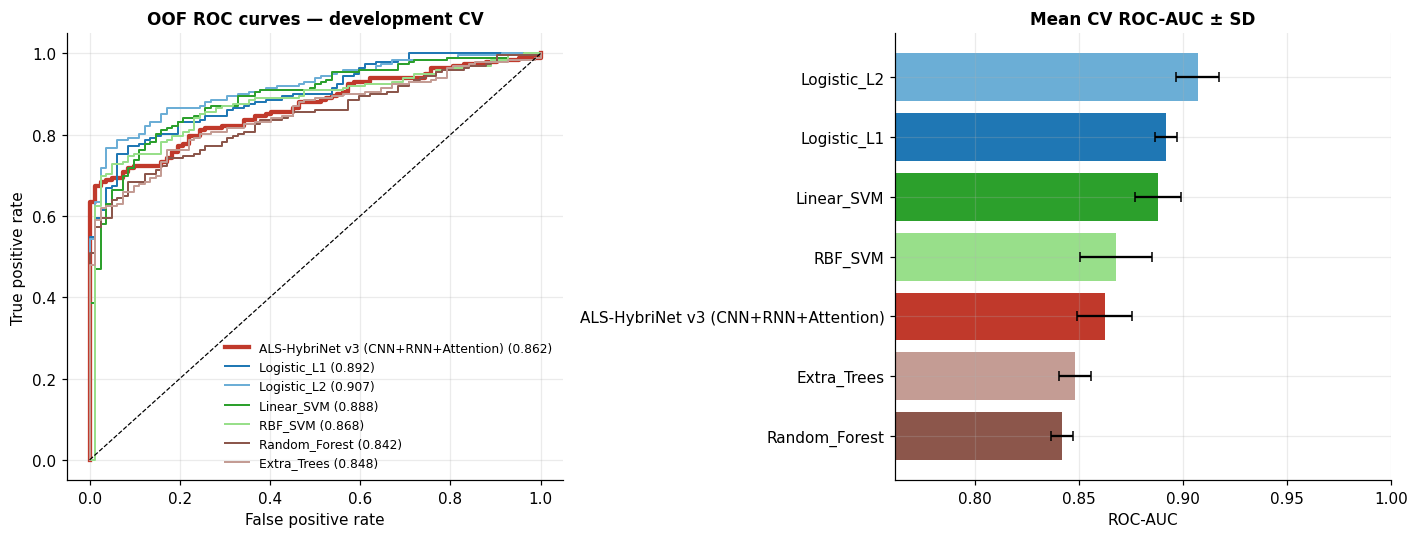

Figure 01 — Internal cross-validated discrimination of all models   [Figure_01_internal_cv_performance.png]


In [9]:
# ======================================================================
# BLOCK 9 — INTERNAL CV COMPARISON
# ======================================================================
banner("BLOCK 9 — INTERNAL CROSS-VALIDATION COMPARISON")

cv_rows = []
for name in MODELS:
    r = CV_RESULTS[name]
    m = classification_metrics(y_dev, r["oof"], r["threshold"])
    cv_rows.append({"model": name, "cv_roc_auc": r["cv_roc_auc"], "cv_roc_auc_sd": r["cv_roc_auc_sd"], "cv_pr_auc": r["cv_pr_auc"],
                    "balanced_accuracy": m["balanced_accuracy"], "sensitivity": m["sensitivity"], "specificity": m["specificity"],
                    "f1": m["f1"], "mcc": m["mcc"], "threshold": r["threshold"]})
cv_table = pd.DataFrame(cv_rows).sort_values("cv_roc_auc", ascending=False).reset_index(drop=True)
cv_table.insert(0, "cv_rank", np.arange(1, len(cv_table) + 1))
REPORT.table(cv_table, "internal_cv_comparison", "Internal cross-validated performance (OOF, development cohort, fold-safe preprocessing)",
             maximize=["cv_roc_auc", "cv_pr_auc", "balanced_accuracy", "f1", "mcc"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name in MODELS:
    fpr, tpr, _ = roc_curve(y_dev, CV_RESULTS[name]["oof"])
    lw = 2.8 if name == PROPOSED else 1.3
    axes[0].plot(fpr, tpr, lw=lw, color=MODEL_COLORS[name], label=f"{name} ({CV_RESULTS[name]['cv_roc_auc']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[0].set(title="OOF ROC curves — development CV", xlabel="False positive rate", ylabel="True positive rate")
axes[0].legend(fontsize=8, loc="lower right")
order = cv_table["model"].tolist()[::-1]
axes[1].barh(order, cv_table.set_index("model").loc[order, "cv_roc_auc"],
             xerr=cv_table.set_index("model").loc[order, "cv_roc_auc_sd"], color=[MODEL_COLORS[m] for m in order], capsize=3)
axes[1].set(xlim=(max(0.5, cv_table["cv_roc_auc"].min() - 0.08), 1.0), title="Mean CV ROC-AUC ± SD", xlabel="ROC-AUC")
fig.tight_layout()
REPORT.figure(fig, "internal_cv_performance", "Internal cross-validated discrimination of all models")


## Block 10 — Held-out test evaluation (scored once)

All models, preprocessing (fit on the full development set) and thresholds are frozen before this block runs.


BLOCK 10 — HELD-OUT TEST EVALUATION


Test metrics:   0%|          | 0/7 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------------
Table 07 — Held-out test performance (scored once)
------------------------------------------------------------------------------------------------


test_rank,model,roc_auc,roc_auc_ci,pr_auc,balanced_accuracy,sensitivity,specificity,f1,mcc,brier,ece
1,ALS-HybriNet v3 (CNN+RNN+Attention),0.9057,"[0.830, 0.965]",0.9660,0.8347,0.7647,0.9048,0.8478,0.6145,0.1195,0.0893
2,RBF_SVM,0.8478,"[0.746, 0.930]",0.9374,0.7871,0.7647,0.8095,0.8298,0.5322,0.1473,0.1019
3,Extra_Trees,0.8338,"[0.726, 0.915]",0.9388,0.7941,0.5882,1.0000,0.7407,0.5423,0.1474,0.0882
4,Logistic_L1,0.8329,"[0.730, 0.921]",0.9329,0.7577,0.7059,0.8095,0.7912,0.4715,0.1801,0.1585
5,Random_Forest,0.8226,"[0.712, 0.911]",0.9358,0.8137,0.6275,1.0000,0.7711,0.5739,0.1515,0.1124
6,Linear_SVM,0.8067,"[0.697, 0.901]",0.9197,0.7241,0.6863,0.7619,0.7692,0.4100,0.1621,0.0935
7,Logistic_L2,0.7899,"[0.674, 0.889]",0.9137,0.7143,0.6667,0.7619,0.7556,0.3910,0.1972,0.1902


[Table_07_test_ranking.csv]

------------------------------------------------------------------------------------------------
Table 08 — Paired DeLong ROC-AUC comparisons on the held-out test set
------------------------------------------------------------------------------------------------


comparison,auc_difference,z,p_value,p_holm,conclusion
ALS-HybriNet v3 (CNN+RNN+Attention) vs Logistic_L2,0.1158,2.6160,0.0089,0.0534,no significant difference
ALS-HybriNet v3 (CNN+RNN+Attention) vs Linear_SVM,0.0990,2.2991,0.0215,0.1075,no significant difference
ALS-HybriNet v3 (CNN+RNN+Attention) vs Random_Forest,0.0831,2.0199,0.0434,0.1736,no significant difference
ALS-HybriNet v3 (CNN+RNN+Attention) vs Logistic_L1,0.0728,1.9226,0.0545,0.1736,no significant difference
ALS-HybriNet v3 (CNN+RNN+Attention) vs Extra_Trees,0.0719,1.7438,0.0812,0.1736,no significant difference
ALS-HybriNet v3 (CNN+RNN+Attention) vs RBF_SVM,0.0579,1.2836,0.1993,0.1993,no significant difference


[Table_08_delong_tests.csv]

Test-set top model (by ROC-AUC): ALS-HybriNet v3 (CNN+RNN+Attention)
ALS-HybriNet v3 (CNN+RNN+Attention): test rank 1 of 7, internal CV rank 5 of 7.
⚠ Note the gap: ALS-HybriNet v3 (CNN+RNN+Attention) ranks 1 on the single held-out test split but 5 across 15 CV folds. With only 72 test patients the single-split ranking is noisy; the cross-validated rank is the more reliable estimate and should be the headline number, not the test rank alone.


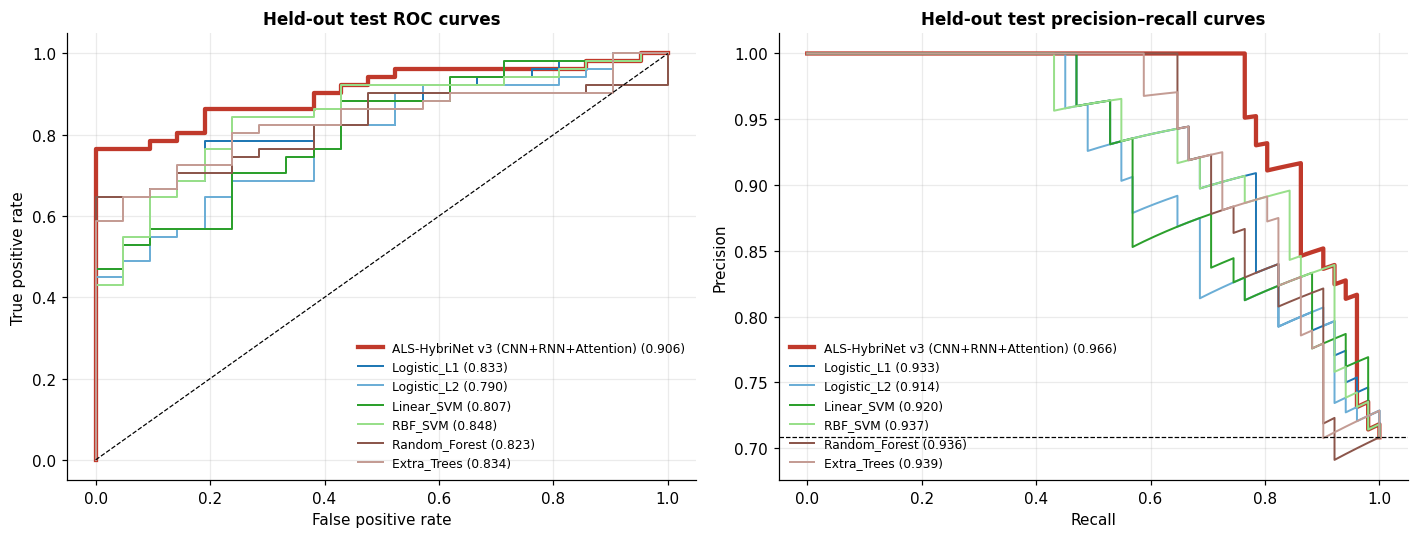

Figure 02 — Held-out test ROC and precision–recall curves   [Figure_02_test_roc_pr.png]


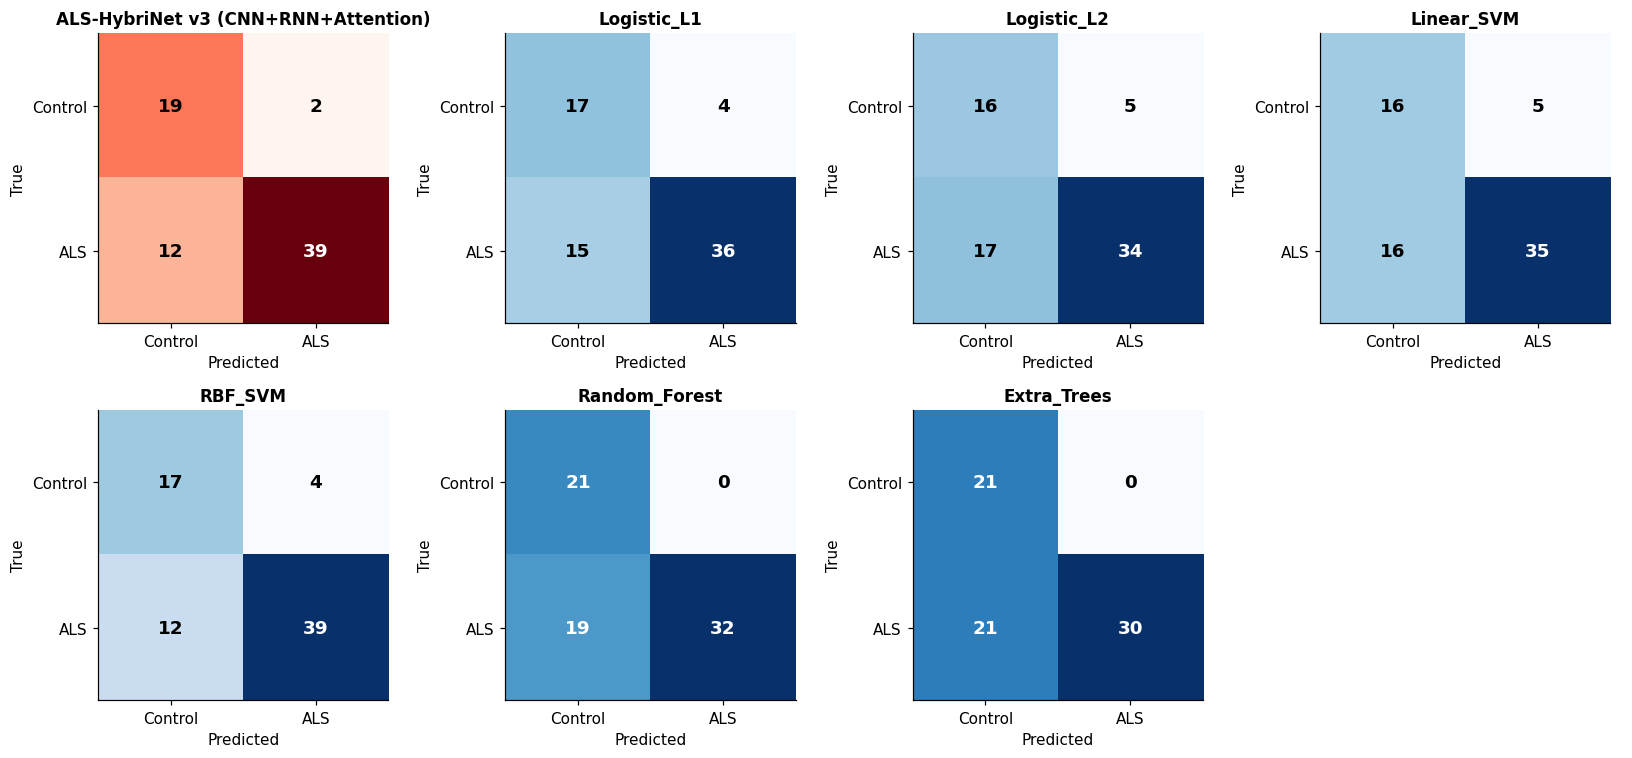

Figure 03 — Held-out test confusion matrices at frozen OOF-derived thresholds   [Figure_03_test_confusion_matrices.png]


In [10]:
# ======================================================================
# BLOCK 10 — HELD-OUT TEST EVALUATION
# ======================================================================
banner("BLOCK 10 — HELD-OUT TEST EVALUATION")

P_TEST = {name: FINAL_BASELINES[name].predict_proba(X_test_final)[:, 1] for name in BASELINES}
P_TEST[PROPOSED] = predict_ensemble(FINAL_MM, TEST_GLOBAL)

rng = np.random.default_rng(CFG.seed)
pos_i, neg_i = np.where(y_test == 1)[0], np.where(y_test == 0)[0]
boot_idx = [np.concatenate([rng.choice(pos_i, len(pos_i)), rng.choice(neg_i, len(neg_i))]) for _ in range(CFG.n_bootstrap)]

test_rows, ci_rows = [], []
for name in tqdm(MODELS, desc="Test metrics"):
    thr = CV_RESULTS[name]["threshold"]
    m = classification_metrics(y_test, P_TEST[name], thr)
    boots = {"roc_auc": [], "pr_auc": [], "balanced_accuracy": [], "mcc": []}
    for b in boot_idx:
        yb, pb = y_test[b], P_TEST[name][b]
        pred = (pb >= thr).astype(int)
        sens, spec = (pred[yb == 1] == 1).mean(), (pred[yb == 0] == 0).mean()
        boots["roc_auc"].append(roc_auc_score(yb, pb))
        boots["pr_auc"].append(average_precision_score(yb, pb))
        boots["balanced_accuracy"].append((sens + spec) / 2)
        boots["mcc"].append(matthews_corrcoef(yb, pred))
    ci = {f"{k}_ci": f"[{np.percentile(v, 2.5):.3f}, {np.percentile(v, 97.5):.3f}]" for k, v in boots.items()}
    ci_rows.append({"model": name, **{k: np.percentile(v, [2.5, 97.5]) for k, v in boots.items()}})
    test_rows.append({"model": name, **m, **ci, "threshold": thr})

test_table = pd.DataFrame(test_rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
test_table.insert(0, "test_rank", np.arange(1, len(test_table) + 1))
test_table.to_csv(DIRS["metrics"] / "held_out_test_metrics.csv", index=False)
cols = ["test_rank", "model", "roc_auc", "roc_auc_ci", "pr_auc", "balanced_accuracy", "sensitivity", "specificity", "f1", "mcc", "brier", "ece"]
REPORT.table(test_table[cols], "test_ranking", "Held-out test performance (scored once)",
             maximize=["roc_auc", "pr_auc", "balanced_accuracy", "f1", "mcc"], minimize=["brier", "ece"])

dl = []
for name in BASELINES:
    diff, z, p = delong_test(y_test, P_TEST[PROPOSED], P_TEST[name])
    dl.append({"comparison": f"{PROPOSED} vs {name}", "auc_difference": diff, "z": z, "p_value": p})
dl = pd.DataFrame(dl).sort_values("p_value").reset_index(drop=True)
m_tests = len(dl)
dl["p_holm"] = np.minimum(1, np.maximum.accumulate((m_tests - np.arange(m_tests)) * dl["p_value"]))
dl["conclusion"] = np.where(dl["p_holm"] < 0.05, np.where(dl["auc_difference"] > 0, "proposed significantly better", "proposed significantly worse"), "no significant difference")
REPORT.table(dl, "delong_tests", "Paired DeLong ROC-AUC comparisons on the held-out test set", model_col="comparison")

winner = test_table.iloc[0]["model"]
proposed_rank = int(test_table.loc[test_table["model"] == PROPOSED, "test_rank"].iloc[0])
cv_rank_proposed = int(cv_table.loc[cv_table["model"] == PROPOSED, "cv_rank"].iloc[0])
print(f"\nTest-set top model (by ROC-AUC): {winner}")
print(f"{PROPOSED}: test rank {proposed_rank} of {len(MODELS)}, internal CV rank {cv_rank_proposed} of {len(MODELS)}.")
if proposed_rank == 1 and cv_rank_proposed > 2:
    print(f"⚠ Note the gap: {PROPOSED} ranks {proposed_rank} on the single held-out test split but {cv_rank_proposed} "
          f"across {len(FOLDS)} CV folds. With only {int(TEST.sum())} test patients the single-split ranking is noisy; "
          "the cross-validated rank is the more reliable estimate and should be the headline number, not the test rank alone.")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name in MODELS:
    lw = 2.8 if name == PROPOSED else 1.3
    fpr, tpr, _ = roc_curve(y_test, P_TEST[name])
    prec, rec, _ = precision_recall_curve(y_test, P_TEST[name])
    m = test_table.set_index("model").loc[name]
    axes[0].plot(fpr, tpr, lw=lw, color=MODEL_COLORS[name], label=f"{name} ({m['roc_auc']:.3f})")
    axes[1].plot(rec, prec, lw=lw, color=MODEL_COLORS[name], label=f"{name} ({m['pr_auc']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[1].axhline(y_test.mean(), color="k", ls="--", lw=0.8)
axes[0].set(title="Held-out test ROC curves", xlabel="False positive rate", ylabel="True positive rate")
axes[1].set(title="Held-out test precision–recall curves", xlabel="Recall", ylabel="Precision")
for ax in axes:
    ax.legend(fontsize=8, loc="lower right" if ax is axes[0] else "lower left")
fig.tight_layout()
REPORT.figure(fig, "test_roc_pr", "Held-out test ROC and precision–recall curves")

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for ax, name in zip(axes.ravel(), MODELS):
    cm = confusion_matrix(y_test, (P_TEST[name] >= CV_RESULTS[name]["threshold"]).astype(int), labels=[0, 1])
    ax.imshow(cm, cmap="Reds" if name == PROPOSED else "Blues")
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, v, ha="center", va="center", fontsize=12, fontweight="bold", color="white" if v > cm.max() / 2 else "black")
    ax.set_xticks([0, 1], ["Control", "ALS"]); ax.set_yticks([0, 1], ["Control", "ALS"])
    ax.set(title=name, xlabel="Predicted", ylabel="True"); ax.grid(False)
for ax in axes.ravel()[len(MODELS):]:
    ax.axis("off")
fig.tight_layout()
REPORT.figure(fig, "test_confusion_matrices", "Held-out test confusion matrices at frozen OOF-derived thresholds")
MANIFEST["test"] = {"winner": winner, "proposed_test_rank": proposed_rank, "proposed_cv_rank": cv_rank_proposed,
                    "proposed_roc_auc": float(test_table.set_index("model").loc[PROPOSED, "roc_auc"])}


## Block 11 — Explainability: SHAP, modality attention, temporal attention

All attributions are computed on the **development** cohort, so biomarker discovery never depends on the held-out test labels. SHAP uses a torch-native `GradientExplainer` (numerically stable at this feature count); the earlier `KernelExplainer` produced unstable attributions and is not used. Both global (population-level) and per-patient SHAP are reported.


BLOCK 11 — EXPLAINABILITY
✓ SHAP values computed for 150 development patients (GradientExplainer, numerically checked).

------------------------------------------------------------------------------------------------
Table 09 — Top 30 miRNAs by CNN-branch attribution (GradientExplainer)
------------------------------------------------------------------------------------------------


mirna,family,mean_abs_attribution
hsa-miR-206,mir-206,0.0335
hsa-miR-2276-5p,mir-2276,0.0195
hsa-miR-484,mir-484,0.0191
hsa-miR-3687,mir-3687,0.0185
hsa-miR-7975,mir-7975,0.0171
hsa-miR-9-3p,mir-9,0.0169
hsa-miR-205-5p,mir-205,0.0163
hsa-miR-20a-5p,mir-20a,0.0161
hsa-miR-4473,mir-4473,0.0161
hsa-miR-214-3p,mir-214,0.0161


[Table_09_top_mirna.csv]
miR-181 family attribution rank(s) in this model: [258, 312, 316, 485] of 512 (the source publication identifies circulating miR-181 as the primary ALS prognostic biomarker).


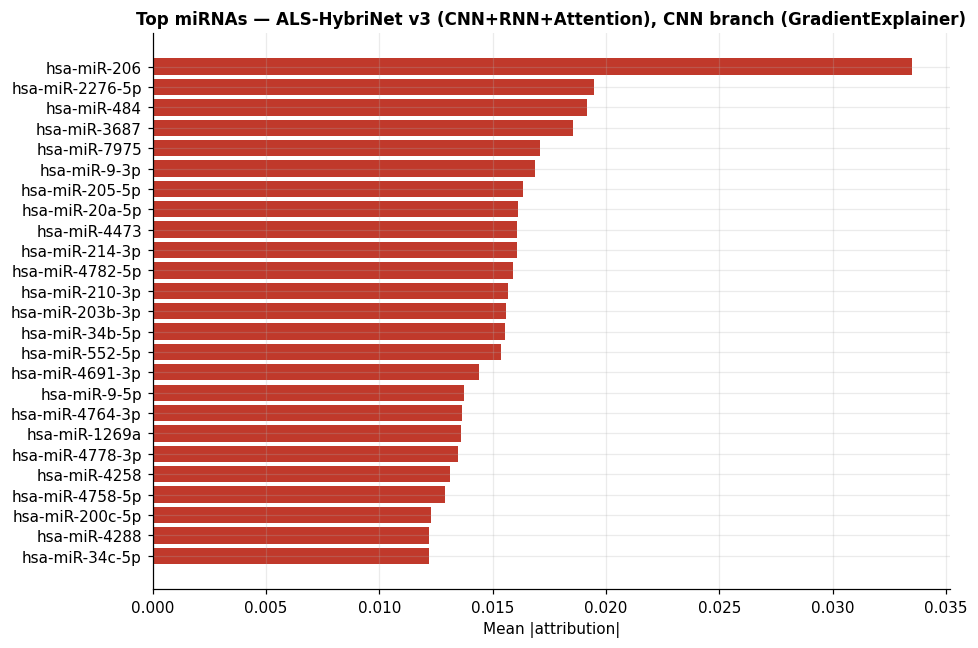

Figure 04 — CNN-branch miRNA attribution   [Figure_04_cnn_mirna_attribution.png]

------------------------------------------------------------------------------------------------
Table 10 — Per-patient top-5 miRNA attributions, 5 example patients (GradientExplainer)
------------------------------------------------------------------------------------------------


patient_id,rank,mirna,attribution
BLT00006,1,hsa-miR-206,0.0299
BLT00006,2,hsa-miR-7975,-0.0291
BLT00006,3,hsa-miR-1203,0.0267
BLT00006,4,hsa-miR-4785,-0.0266
BLT00006,5,hsa-miR-330-5p,0.0250
BUH00010,1,hsa-miR-203b-3p,-0.0333
BUH00010,2,hsa-miR-7975,-0.0252
BUH00010,3,hsa-miR-5699-5p,0.0207
BUH00010,4,hsa-miR-8066,0.0170
BUH00010,5,hsa-miR-4758-5p,0.0158


[Table_10_per_patient_shap.csv]

------------------------------------------------------------------------------------------------
Table 11 — Mean CNN vs RNN attention weight, by whether longitudinal data was present
------------------------------------------------------------------------------------------------


rnn_data_present,cnn_weight,rnn_weight
False,1.0000,0.0000
True,0.0083,0.9917


[Table_11_modality_attention.csv]
⚠ The model places most of its attention on the RNN branch whenever it is present. Because RNN availability is itself perfectly confounded with being an ALS patient in this cohort (no control has longitudinal data), this may partly reflect 'RNN present' acting as a proxy for the label rather than the RNN branch's content alone -- a known limitation given this dataset's structure, flagged here rather than presented as a clean modality-fusion result.


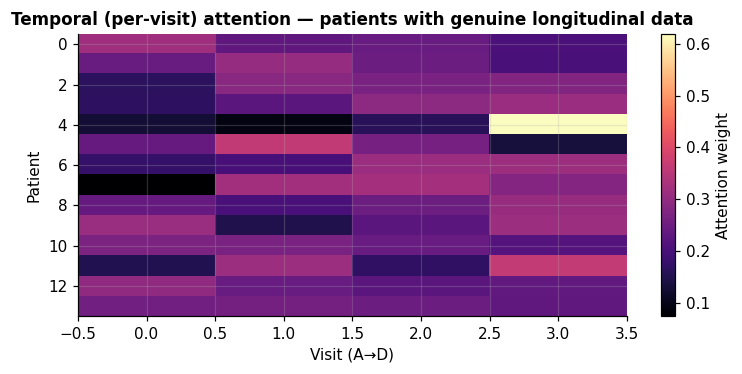

Figure 05 — RNN branch: per-visit attention weights, longitudinal patients only   [Figure_05_temporal_attention.png]


In [11]:
# ======================================================================
# BLOCK 11 — EXPLAINABILITY
# ======================================================================
banner("BLOCK 11 — EXPLAINABILITY")

HAS_SHAP = ensure_package("shap")
model0, prep0 = FINAL_MM[0]
Xs_dev_cnn = torch.tensor(cnn_input(prep0, DEV_GLOBAL), device=DEVICE)


class _CNNOnlyExplainWrapper(nn.Module):
    """Wraps the full model with the RNN branch forced absent (present=0), matching how the model
    already behaves for the 89% of patients with no longitudinal data -- a single differentiable
    torch.nn.Module, which GradientExplainer needs (KernelExplainer's black-box linear solve is what
    produced the earlier numerically unstable attributions at this feature count)."""

    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        n = x.shape[0]
        modality_present = None
        if self.model.use_rnn and self.model.use_cnn:
            modality_present = torch.stack([torch.ones(n, device=x.device), torch.zeros(n, device=x.device)], dim=1)
        return torch.sigmoid(self.model(x_mirna=x, visit_seq=None, visit_mask=None, modality_present=modality_present)).unsqueeze(-1)


explain_wrapper = _CNNOnlyExplainWrapper(model0).to(DEVICE).eval()

gene_shap = None
shap_method = None
if HAS_SHAP:
    try:
        import shap
        rng_ = np.random.RandomState(CFG.seed)
        background = Xs_dev_cnn[rng_.choice(len(Xs_dev_cnn), size=min(60, len(Xs_dev_cnn)), replace=False)]
        sample = Xs_dev_cnn[:min(150, len(Xs_dev_cnn))]
        explainer = shap.GradientExplainer(explain_wrapper, background)
        sv = explainer.shap_values(sample)
        gene_shap = np.asarray(sv)
        if gene_shap.ndim == 3:            # (n_samples, n_features, n_outputs) -> squeeze the single output
            gene_shap = gene_shap[..., 0]
        if not np.isfinite(gene_shap).all() or np.abs(gene_shap).max() > 1e3:
            raise ValueError(f"GradientExplainer produced non-finite or implausibly large values (max abs = {np.nanmax(np.abs(gene_shap)):.3g})")
        shap_method = "GradientExplainer"
        print(f"✓ SHAP values computed for {sample.shape[0]} development patients (GradientExplainer, numerically checked).")
    except Exception as err:
        print(f"⚠ SHAP computation failed or was numerically unstable ({err}); falling back to gradient × input attribution.")
        gene_shap = None

if gene_shap is None:
    grads = []
    for i in range(0, len(Xs_dev_cnn), 64):
        xb = Xs_dev_cnn[i:i + 64].clone().requires_grad_(True)
        model0.cnn(xb).sum().backward()
        grads.append((xb.grad * xb).detach().cpu().numpy())
    gene_shap = np.concatenate(grads)
    shap_method = "gradient_x_input"
    print("Using gradient × input as the CNN attribution method (SHAP unavailable or unstable).")

# ----------------------------------------------------------------------
# Global (population-level) miRNA ranking
# ----------------------------------------------------------------------
attr_ordered = np.abs(gene_shap).mean(0)
attr = np.zeros_like(attr_ordered)
attr[prep0["family_perm"]] = attr_ordered

mirna_imp = pd.DataFrame({"mirna": prep0["sel_names"], "family": [mirna_family(g) for g in prep0["sel_names"]], "mean_abs_attribution": attr}
                         ).sort_values("mean_abs_attribution", ascending=False).reset_index(drop=True)
mirna_imp.to_csv(DIRS["biomarkers"] / "cnn_branch_mirna_attribution.csv", index=False)
REPORT.table(mirna_imp.head(30), "top_mirna", f"Top 30 miRNAs by CNN-branch attribution ({shap_method})", model_col="mirna")

known = mirna_imp[mirna_imp["mirna"].str.contains("181", case=False)]
if len(known):
    print(f"miR-181 family attribution rank(s) in this model: {known.index.tolist()} of {len(mirna_imp)} "
          f"(the source publication identifies circulating miR-181 as the primary ALS prognostic biomarker).")

fig, ax = plt.subplots(figsize=(9, 6))
top = mirna_imp.head(25).iloc[::-1]
ax.barh(top["mirna"], top["mean_abs_attribution"], color="#C0392B")
ax.set(title=f"Top miRNAs — {PROPOSED}, CNN branch ({shap_method})", xlabel="Mean |attribution|")
fig.tight_layout()
REPORT.figure(fig, "cnn_mirna_attribution", "CNN-branch miRNA attribution")

# ----------------------------------------------------------------------
# Per-patient SHAP: 5 example patients (not just the global mean)
# ----------------------------------------------------------------------
example_n = min(5, gene_shap.shape[0])
example_pos = np.linspace(0, gene_shap.shape[0] - 1, example_n).astype(int)
example_ids = ids_dev[example_pos] if "ids_dev" in dir() else baseline_ids[DEV_GLOBAL][example_pos]
per_patient_rows = []
for pos, pid in zip(example_pos, example_ids):
    patient_attr_ordered = gene_shap[pos]
    patient_attr = np.zeros_like(patient_attr_ordered)
    patient_attr[prep0["family_perm"]] = patient_attr_ordered
    top5 = np.argsort(np.abs(patient_attr))[::-1][:5]
    for rank, idx in enumerate(top5, 1):
        per_patient_rows.append({"patient_id": pid, "rank": rank, "mirna": prep0["sel_names"][idx], "attribution": float(patient_attr[idx])})
per_patient_df = pd.DataFrame(per_patient_rows)
per_patient_df.to_csv(DIRS["biomarkers"] / "per_patient_shap_examples.csv", index=False)
REPORT.table(per_patient_df, "per_patient_shap", f"Per-patient top-5 miRNA attributions, {example_n} example patients ({shap_method})", precision=4, model_col="patient_id")

# ----------------------------------------------------------------------
# Modality attention: does the model rely more on RNN when it is present?
# ----------------------------------------------------------------------
ids_dev = baseline_ids[DEV_GLOBAL]
_, _, present = visit_batch(prep0, ids_dev)
with torch.no_grad():
    _forward_batch(model0, prep0, Xs_dev_cnn, ids_dev)
if model0.last_weights is not None:
    w = model0.last_weights.cpu().numpy()
    modality_df = pd.DataFrame({"patient_id": ids_dev, "cnn_weight": w[:, 0], "rnn_weight": w[:, 1],
                                "rnn_data_present": present.cpu().numpy().astype(bool), "label": np.where(y_dev == 1, "ALS", "Control")})
    mod_summary = modality_df.groupby("rnn_data_present")[["cnn_weight", "rnn_weight"]].mean().reset_index()
    REPORT.table(mod_summary, "modality_attention", "Mean CNN vs RNN attention weight, by whether longitudinal data was present")
    if present.cpu().numpy().astype(bool).any() and mod_summary.set_index("rnn_data_present").loc[True, "rnn_weight"] > 0.8:
        print("⚠ The model places most of its attention on the RNN branch whenever it is present. Because RNN "
              "availability is itself perfectly confounded with being an ALS patient in this cohort (no control "
              "has longitudinal data), this may partly reflect 'RNN present' acting as a proxy for the label "
              "rather than the RNN branch's content alone -- a known limitation given this dataset's structure, "
              "flagged here rather than presented as a clean modality-fusion result.")

if model0.rnn.last_attention is not None and LONGITUDINAL:
    temporal = model0.rnn.last_attention.cpu().numpy()
    has_data = present.cpu().numpy().astype(bool)
    if has_data.any():
        fig, ax = plt.subplots(figsize=(7, 3.5))
        im = ax.imshow(temporal[has_data], aspect="auto", cmap="magma")
        ax.set(title="Temporal (per-visit) attention — patients with genuine longitudinal data", xlabel="Visit (A→D)", ylabel="Patient")
        fig.colorbar(im, ax=ax, label="Attention weight")
        fig.tight_layout()
        REPORT.figure(fig, "temporal_attention", "RNN branch: per-visit attention weights, longitudinal patients only")

MANIFEST["explainability"] = {"method": shap_method, "top_mirna": mirna_imp["mirna"].head(30).tolist(),
                              "per_patient_examples": example_ids.tolist()}


## Block 12 — Ablation study: CNN-only vs RNN-only vs CNN+RNN vs CNN+RNN+Attention


BLOCK 12 — ABLATION STUDY


Ablations:   0%|          | 0/4 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------------
Table 12 — Ablation of ALS-HybriNet v3 (CNN+RNN+Attention) components (CV = first repeat; test = seed ensemble; fold-safe preprocessing)
------------------------------------------------------------------------------------------------


variant,cv_roc_auc,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_specificity,test_mcc
ALS-HybriNet v3 (CNN+RNN+Attention) (full),0.8803,0.9141,0.9682,0.8249,0.9048,0.5944
CNN only,0.8459,0.8515,0.9430,0.7955,0.9048,0.5375
RNN only,0.5412,0.4178,0.7541,0.5784,1.0000,0.2269
"CNN + RNN, no attention (concat)",0.8532,0.8842,0.9551,0.8039,1.0000,0.5580


[Table_12_ablation.csv]


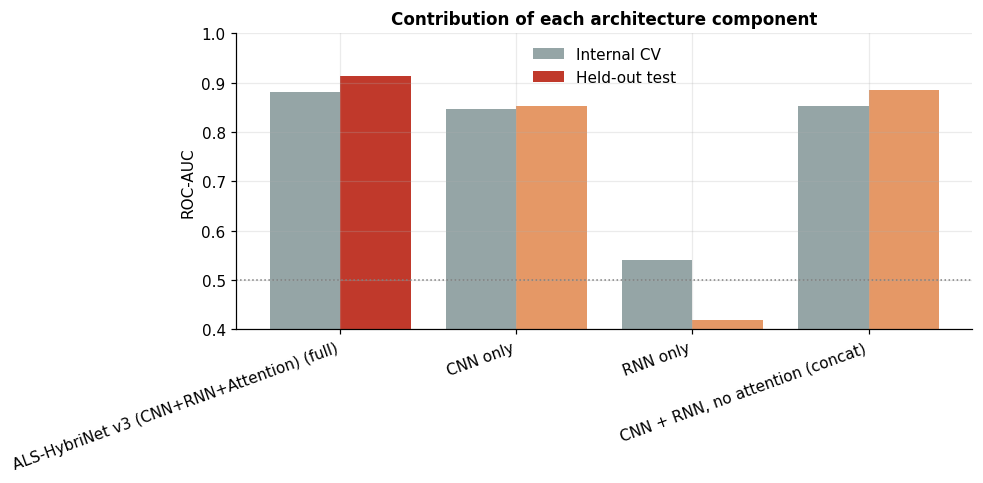

Figure 06 — Ablation study of ALS-HybriNet v3 (CNN+RNN+Attention)   [Figure_06_ablation.png]


In [12]:
# ======================================================================
# BLOCK 12 — ABLATION STUDY
# ======================================================================
banner("BLOCK 12 — ABLATION STUDY")

first_repeat = FOLDS[:CFG.n_folds]


def run_ablation(label, use_cnn, use_rnn, use_attention):
    oof, epochs_used = np.zeros(N_DEV), []
    for f, (tr, va) in enumerate(first_repeat):
        model, prep, be = train_multimodal(DEV_GLOBAL[tr], HP_SELECTED, seed=CFG.seed + f, use_cnn=use_cnn, use_rnn=use_rnn, use_attention=use_attention)
        oof[va] = predict_multimodal(model, prep, DEV_GLOBAL[va])
        epochs_used.append(be)
    members = [train_multimodal(DEV_GLOBAL, HP_SELECTED, seed=s, epochs=int(math.ceil(np.median(epochs_used) * 1.1)),
                                use_cnn=use_cnn, use_rnn=use_rnn, use_attention=use_attention)[:2] for s in CFG.ablation_seeds]
    p_test = predict_ensemble(members, TEST_GLOBAL)
    thr = youden_threshold(y_dev, oof)
    m = classification_metrics(y_test, p_test, thr)
    return {"variant": label, "cv_roc_auc": roc_auc_score(y_dev, oof), "test_roc_auc": m["roc_auc"], "test_pr_auc": m["pr_auc"],
            "test_balanced_accuracy": m["balanced_accuracy"], "test_specificity": m["specificity"], "test_mcc": m["mcc"]}


ABLATIONS = [
    (f"{PROPOSED} (full)", True, True, True),
    ("CNN only", True, False, True),
    ("RNN only", False, True, True),
    ("CNN + RNN, no attention (concat)", True, True, False),
]
abl_rows = [run_ablation(label, uc, ur, ua) for label, uc, ur, ua in tqdm(ABLATIONS, desc="Ablations")]
abl = pd.DataFrame(abl_rows)
REPORT.table(abl, "ablation", f"Ablation of {PROPOSED} components (CV = first repeat; test = seed ensemble; fold-safe preprocessing)",
             maximize=["cv_roc_auc", "test_roc_auc", "test_pr_auc", "test_balanced_accuracy", "test_mcc"], model_col="variant")

fig, ax = plt.subplots(figsize=(9, 4.5))
xpos = np.arange(len(abl))
ax.bar(xpos - 0.2, abl["cv_roc_auc"], 0.4, label="Internal CV", color="#95A5A6")
ax.bar(xpos + 0.2, abl["test_roc_auc"], 0.4, label="Held-out test", color=["#C0392B"] + ["#E59866"] * (len(abl) - 1))
ax.set_xticks(xpos, abl["variant"], rotation=20, ha="right")
ax.axhline(0.5, color="grey", ls=":", lw=1)
ax.set(ylim=(0.4, 1.0), ylabel="ROC-AUC", title="Contribution of each architecture component")
ax.legend()
fig.tight_layout()
REPORT.figure(fig, "ablation", f"Ablation study of {PROPOSED}")
